## Copula Estimation for the positional marginals

Models the dependence structure of one manager's whole squad with a truncated C-vine
copula over their personalized marginals (from `longitudinal.ipynb`'s
`fit_manager_pipeline` / `alpha_manager`). Split out into its own notebook since it's a
distinct modelling stage with its own dependency (`pyvinecopulib`) and its own data
requirement (enough historical weeks for Kendall's tau to be meaningful -- see the
caveat near the bottom).

Bivariate copula fitting, AIC-based family selection, and vine simulation use
`pyvinecopulib` rather than a from-scratch implementation.

One correction to the write-up: the stated boundary formulas
$a_{t,k}=(1-X_{t,k})(1-p_{t,k})$, $b_{t,k}=X_{t,k}+(1-X_{t,k})(1-p_{t,k})$ collapse to
$a=b=1-p_{t,k}$ when $X_{t,k}=0$ (a zero-width interval, not the stated
$[0, 1-p_{t,k})$). The cases actually given for $u_{t,k}$'s support --
$[0, 1-p_{t,k})$ when not selected, $[1-p_{t,k}, 1]$ when selected -- are unambiguous and
are exactly the standard _distributional transform_ used to continuize a discrete
(here Bernoulli($p_{t,k}$)) margin for copula modelling, so that's what's implemented
below: $a_{t,k} = X_{t,k}\cdot(1-p_{t,k})$, $b_{t,k} = X_{t,k} + (1-X_{t,k})(1-p_{t,k})$.


### Setup

Reloads what this stage needs from `longitudinal.ipynb`: the raw data, the league
fits (for `feats`/`X_mean`/`X_std`/`beta_mean`), and the position-pool/`alpha_manager`
helpers. Doesn't re-run any PyMC fitting -- it loads a `manager_fits_{GW}.joblib`
already produced by `longitudinal.ipynb`'s per-round loop.


In [4]:
import ast

import numpy as np
import pandas as pd
import joblib
import pyvinecopulib as pv
from scipy.stats import kendalltau

player_data = pd.read_csv('../../rolled_data_24_25.csv')
league_selections = pd.read_csv('../../league_selections_df.csv')

LEAGUE_FITS = {
    'Goalkeeper': joblib.load('../estimates/league_models_gk'),
    'Defender': joblib.load('../estimates/league_models_def'),
    'Midfielder': joblib.load('../estimates/league_models_mid'),
    'Forward': joblib.load('../estimates/league_models_fwd'),
}

POSITION_BINARY_COL = {
    'Goalkeeper': 'goalkeeper_binary',
    'Defender': 'defender_binary',
    'Midfielder': 'midfielder_binary',
    'Forward': 'forward_binary',
}

SQUAD_SLOTS = {'Goalkeeper': 2, 'Defender': 5, 'Midfielder': 5, 'Forward': 3}


def get_league_fit_for_round(league_fits, target_round):
    """Pick the league fit at `target_round`, or the most recent one available
    before it (see longitudinal.ipynb for the full rationale)."""
    available = [gw for gw in league_fits if gw <= target_round]
    if not available:
        raise ValueError(f"No league fit available at or before round {target_round}")
    return league_fits[max(available)]


def _position_pool(player_data, position, rnd, feats):
    """The player pool for `position` at gameweek `rnd`, sorted by element id
    ascending -- matches the *_binary columns in league_selections for that round."""
    pool = player_data[(player_data['round'] == rnd) & (player_data['position'] == position)] \
        .sort_values('element')
    elements = pool['element'].to_numpy()
    X_raw = pool[feats].fillna(0).to_numpy(dtype=float)
    return elements, X_raw


def alpha_manager(manager_fit, league_fit, X_new_raw, y_prev):
    """alpha_{j,m,t,k} (eq:alpha_m) for a fitted manager model at new raw features
    X_new_raw and retention lag y_prev."""
    X_std_new = (X_new_raw - league_fit["X_mean"]) / league_fit["X_std"]
    beta_m = league_fit["beta_mean"] + manager_fit["delta_beta_mean"]
    linear = X_std_new @ beta_m + manager_fit["gamma_mean"] * y_prev
    linear = np.clip(linear, -30, 30)
    return np.exp(linear)


def marginal_inclusion_probabilities(weights, k, rng, n_sim=3000):
    """
    Efraimidis-Spirakis (A-ES) weighted sampling without replacement: draw
    key_i = U_i^(1/w_i) for U_i~Uniform(0,1), take the k items with the largest keys.
    This reproduces exactly sequential (Plackett-Luce) weighted sampling without
    replacement, and by linearity of expectation the resulting per-item inclusion
    probabilities always sum to exactly k -- turning `weights` (alpha_manager's raw,
    arbitrarily-scaled output) into genuine marginal "P(this player is one of the k
    picked)" probabilities. See the markdown above the pool-construction cell for why
    this replaces the naive alpha/alpha.sum() (which sums to 1 per position, not k).
    """
    weights = np.clip(np.asarray(weights, dtype=float), 1e-12, None)
    n = len(weights)
    U = rng.uniform(size=(n_sim, n))
    keys = U ** (1.0 / weights)[None, :]
    topk_idx = np.argpartition(-keys, kth=k - 1, axis=1)[:, :k]
    counts = np.bincount(topk_idx.ravel(), minlength=n)
    return counts / n_sim


def detect_squad_overhaul(team_id, gw, league_selections, threshold=8):
    """
    Flags gameweek `gw` as a likely Wildcard/Free Hit week for `team_id` (see
    longitudinal.ipynb): more than `threshold` of the 15 squad slots changed from
    gw-1's actual squad is the signature of a chip-driven full rebuild, which
    alpha_manager has no signal for. Returns (n_changed, is_overhaul); both None if
    gw-1 or gw isn't in league_selections for this team.
    """
    prev_rows = league_selections[(league_selections['team_id'] == team_id) & (league_selections['round'] == gw - 1)]
    cur_rows = league_selections[(league_selections['team_id'] == team_id) & (league_selections['round'] == gw)]
    if len(prev_rows) == 0 or len(cur_rows) == 0:
        return None, None
    prev_squad = set(ast.literal_eval(prev_rows.iloc[0]['squad']))
    cur_squad = set(ast.literal_eval(cur_rows.iloc[0]['squad']))
    n_changed = len(cur_squad - prev_squad)
    return n_changed, n_changed > threshold


def compute_free_transfers_available(team_id, target_round, league_selections, cap=5, overhaul_threshold=8):
    """
    Simulates `team_id`'s banked free transfers (FTs) entering `target_round`, from
    FPL's accrual rule: 1 new FT per week, unused ones roll over up to `cap` banked at
    once; making more transfers than banked forces a points hit and drains the bank to
    0 (so next week starts back at the baseline 1). GW1 is initial squad formation (no
    transfer concept), so the bank starts at 1 entering GW2.

    Wildcard/Free Hit weeks (flagged by detect_squad_overhaul) are transparent to the
    bank: neither consumes nor resets it, so that week's actual squad-composition
    change is ignored here and the bank just accrues its usual +1 (capped).

    This uses only observed squad snapshots (league_selections), so it can look back
    to GW1 regardless of `min_round` elsewhere in the pipeline (model features aren't
    needed here).
    """
    ft_bank = 1
    for w in range(2, target_round):
        n_changed, is_overhaul = detect_squad_overhaul(team_id, w, league_selections, threshold=overhaul_threshold)
        if n_changed is None:
            continue
        if is_overhaul:
            ft_bank = min(cap, ft_bank + 1)
        elif n_changed <= ft_bank:
            ft_bank = min(cap, (ft_bank - n_changed) + 1)
        else:
            ft_bank = 1
    return ft_bank

In [5]:
# Parameters -- change these to point at a different manager/gameweek's fit.
# manager_fits_{GW}.joblib is produced by longitudinal.ipynb's per-round loop and
# stores {GW: {position: fit_manager_pipeline_result}}.
# GW38/team 13603 was verified via longitudinal.ipynb's calibration sweep to have
# near-perfect marginal ranking across all four positions, ayour full N_SAMPLES=1,000,000 in this sandbox (it timed out at 400s — likely just slower hardware/contention than your own kernel, where it already ran successfully), but I verified the logic correctly at 50,000 samples. Run the new cells at your full 1M in your own kernel to see the actual saturation curve and top squads by frequencnd gives the longest
# available history window (rounds 4-37).
GW = 38
TEAM_ID = 13603

rng = np.random.default_rng(42)
manager_fits = joblib.load(f'./estimates/manager_fits_{GW}.joblib')[GW]
print(f"Loaded manager_fits for GW{GW}, team {TEAM_ID}: positions {list(manager_fits.keys())}")

Loaded manager_fits for GW38, team 13603: positions ['Goalkeeper', 'Defender', 'Midfielder', 'Forward']


### Restricting to the pool $M$

Per position, rank players by their gameweek-`GW` marginal $p_{j,m,GW,k}$ and keep the
top `N_TOP`, unioned with whichever players the manager actually owns that week (so the
observed squad is always representable in $M$, even if the model didn't rank one of
them highly).

**Marginal-probability fix**: `alpha_manager`'s raw output normalizes to sum to exactly
1.0 _per position_ (it's a Dirichlet mean -- a share of that position's total
popularity across e.g. all 260+ defenders), not a per-player selection probability
(which should sum to that position's squad-slot count, e.g. 5 for defenders). Using the
raw share as if it were $P(\text{selected})$ systematically understates it by roughly
the pool size. `marginal_inclusion_probabilities` fixes this properly: it treats the
shares as relative weights and computes each player's true marginal inclusion
probability under weighted sampling of exactly `SQUAD_SLOTS[position]` players without
replacement (Efraimidis-Spirakis), which by construction sums to the slot count exactly.

**A second, more consequential bug this uncovered**: `position_marginals_at_week` was
computing `y_prev` -- whether each player was owned the _previous_ week -- by reusing
gameweek `rnd`'s player pool to interpret gameweek `rnd-1`'s ownership vector. Since the
eligible pool grows most weeks, that length essentially never matched, so `get_owned`
silently returned `None` and `y_prev` came out all zeros -- meaning `gamma_m`'s
retention boost was almost never actually applied here, even though `alpha_manager`
itself is correct and `evaluate_manager_fit` (which recomputes the previous week's pool
fresh) was never affected. Fixed below by recomputing `prev_elements` for `rnd-1`
explicitly, matching what `evaluate_manager_fit` already does.


In [6]:
def get_owned(team_id, position, rnd, elements):
    """Ownership map {element: 0/1} for `position` at round `rnd`, or None if that
    round's selection export doesn't line up with `elements`."""
    rows = league_selections[(league_selections['team_id'] == team_id) & (league_selections['round'] == rnd)]
    if len(rows) == 0:
        return None
    y = np.asarray(ast.literal_eval(rows.iloc[0][POSITION_BINARY_COL[position]]), dtype=float)
    if len(y) != len(elements):
        return None
    return dict(zip(elements.tolist(), y.tolist()))


def position_alpha_at_week(team_id, position, manager_fit, league_fit, rnd):
    """Raw alpha_{j,m,rnd,k} (eq:alpha_m) for every player in `position`'s pool at
    week `rnd`, plus that week's ownership map (or None if unavailable). Used both as
    the weights for marginal_inclusion_probabilities and, later, as the weights for
    keying the vine's correlated draws when constructing full candidate squads."""
    elements, X_raw = _position_pool(player_data, position, rnd, league_fit['feats'])
    # recompute the previous week's pool fresh -- it's a different size than `elements`
    # most weeks, so reusing `elements` here would silently zero out y_prev (see markdown)
    prev_elements, _ = _position_pool(player_data, position, rnd - 1, league_fit['feats'])
    owned_prev_map = get_owned(team_id, position, rnd - 1, prev_elements) or {}
    y_prev = np.array([owned_prev_map.get(e, 0.0) for e in elements])
    alpha = alpha_manager(manager_fit, league_fit, X_raw, y_prev)
    owned_map = get_owned(team_id, position, rnd, elements)
    return dict(zip(elements.tolist(), alpha.tolist())), owned_map


def position_marginals_at_week(team_id, position, manager_fit, league_fit, rnd, rng):
    """p_{k,rnd}, the marginal probability player k is one of position's squad slots
    that week (position_alpha_at_week's weights, rescaled to true selection
    probabilities via marginal_inclusion_probabilities -- see markdown above), plus
    that week's ownership map (or None if unavailable)."""
    alpha_map, owned_map = position_alpha_at_week(team_id, position, manager_fit, league_fit, rnd)
    elements = np.array(list(alpha_map.keys()))
    alpha = np.array(list(alpha_map.values()))
    p = marginal_inclusion_probabilities(alpha, SQUAD_SLOTS[position], rng)
    return dict(zip(elements.tolist(), p.tolist())), owned_map


N_TOP = 30
pool_records = []
for position in ['Goalkeeper', 'Defender', 'Midfielder', 'Forward']:
    manager_fit = manager_fits[position]
    league_fit = get_league_fit_for_round(LEAGUE_FITS[position], GW)
    p_map, owned_map = position_marginals_at_week(TEAM_ID, position, manager_fit, league_fit, GW, rng)

    ranked = sorted(p_map.items(), key=lambda kv: kv[1], reverse=True)
    top_elements = {e for e, _ in ranked[:N_TOP]}
    owned_elements = {e for e, v in (owned_map or {}).items() if v == 1}
    for e in top_elements | owned_elements:
        pool_records.append({"element": e, "position": position})

pool_df = pd.DataFrame(pool_records).sort_values(['position', 'element']).reset_index(drop=True)
elements_ordered = pool_df['element'].tolist()
M = len(elements_ordered)
print(f"Pool M size: {M}  (by position: {pool_df['position'].value_counts().to_dict()})")

Pool M size: 120  (by position: {'Defender': 30, 'Forward': 30, 'Goalkeeper': 30, 'Midfielder': 30})


### Data Augmentation

For every historical week $t$ and every pool player $k$, get $X_{t,k}$ (actual
occupancy) and $p_{t,k}$ (that week's marginal inclusion probability), then draw the
continuized latent uniform via the distributional transform: $u_{t,k} = a_{t,k} +
U\cdot(b_{t,k}-a_{t,k})$ for $U\sim\text{Uniform}(0,1)$, with $a_{t,k}=X_{t,k}(1-p_{t,k})$,
$b_{t,k}=X_{t,k}+(1-X_{t,k})(1-p_{t,k})$ (see the correction noted above).

Weeks flagged by `detect_squad_overhaul` (Wildcard/Free Hit-driven full rebuilds -- see
`longitudinal.ipynb`) are excluded: `alpha_manager` has no signal for a deliberate
one-off squad overhaul, so including those weeks would inject noise into the
Kendall's-$\tau$ dependence estimate rather than real week-to-week co-selection signal.


In [7]:
all_history_rounds = sorted(
    league_selections.loc[
        (league_selections['team_id'] == TEAM_ID) & (league_selections['round'] < GW) & (league_selections['round'] >= 4),
        'round'
    ].unique().tolist()
)
overhaul_rounds = [r for r in all_history_rounds if detect_squad_overhaul(TEAM_ID, r, league_selections)[1]]
history_rounds = [r for r in all_history_rounds if r not in overhaul_rounds]
print(f"history rounds used ({len(history_rounds)}): {history_rounds}")
print(f"excluded as overhaul weeks: {overhaul_rounds}")

X_hist = pd.DataFrame(index=history_rounds, columns=elements_ordered, dtype=float)
P_hist = pd.DataFrame(index=history_rounds, columns=elements_ordered, dtype=float)

for position in ['Goalkeeper', 'Defender', 'Midfielder', 'Forward']:
    manager_fit = manager_fits[position]
    league_fit = get_league_fit_for_round(LEAGUE_FITS[position], GW)
    pos_elements = pool_df.loc[pool_df['position'] == position, 'element'].tolist()
    for rnd in history_rounds:
        p_map, owned_map = position_marginals_at_week(TEAM_ID, position, manager_fit, league_fit, rnd, rng)
        for e in pos_elements:
            X_hist.loc[rnd, e] = (owned_map or {}).get(e, 0.0)
            # a player not yet in the position pool that week (hasn't debuted/transferred
            # into the league yet) gets a tiny floor probability rather than an undefined one
            P_hist.loc[rnd, e] = p_map.get(e, 1e-6)


def latent_uniforms(X_hist, P_hist, rng):
    """Distributional-transform latent uniforms u_{t,k} (see markdown above)."""
    a = np.where(X_hist.values == 0, 0.0, 1.0 - P_hist.values)
    b = np.where(X_hist.values == 0, 1.0 - P_hist.values, 1.0)
    draws = rng.uniform(size=X_hist.shape)
    U = a + draws * (b - a)
    return pd.DataFrame(U, index=X_hist.index, columns=X_hist.columns)


U = latent_uniforms(X_hist, P_hist, rng)
print("U shape:", U.shape)
U.round(3)

history rounds used (30): [4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 33, 36, 37]
excluded as overhaul weeks: [6, 30, 34, 35]
U shape: (30, 120)


,8,24,25,44,45,52,79,100,139,163,...,345,398,402,432,434,463,544,553,696,730
4,0.555,0.894,0.661,0.193,0.639,0.981,0.413,0.412,0.139,0.962,...,0.292,0.977,0.559,0.403,0.519,0.877,0.659,0.441,0.109,0.690
5,0.236,0.253,0.515,0.739,0.454,0.865,0.376,0.678,0.416,0.023,...,0.362,0.966,0.128,0.979,0.566,0.052,0.676,0.140,0.169,0.549
7,0.796,0.930,0.681,0.715,0.437,0.181,0.009,0.282,0.451,0.748,...,0.514,0.858,0.107,0.264,0.348,0.944,0.827,0.275,0.862,0.877
8,0.966,0.759,0.104,0.745,0.959,0.542,0.452,0.100,0.084,0.046,...,0.048,0.071,0.507,0.816,0.089,0.538,0.255,0.542,0.345,0.875
9,0.213,0.316,0.591,0.449,0.104,0.192,0.108,0.939,0.543,0.841,...,0.987,0.857,0.230,0.265,0.944,0.951,0.482,0.640,0.937,0.150
10,0.106,0.257,0.055,0.060,0.926,0.352,0.349,0.168,0.235,0.805,...,0.746,0.511,0.526,0.016,0.456,0.018,0.481,0.951,0.970,0.455
11,0.329,0.169,0.169,0.632,0.251,0.598,0.010,0.685,0.491,0.827,...,0.046,0.333,0.648,0.474,0.526,0.837,0.214,0.302,0.930,0.841
12,0.710,0.829,0.405,0.836,0.114,0.341,0.974,0.340,0.706,0.596,...,0.219,0.026,0.965,0.754,0.423,0.904,0.414,0.008,0.863,0.265
13,0.343,0.098,0.126,0.095,0.085,0.578,0.910,0.210,0.860,0.263,...,0.653,0.023,0.510,0.259,0.333,0.871,0.394,0.286,0.513,0.337
14,0.022,0.461,0.092,0.301,0.466,0.368,0.669,0.638,0.831,0.706,...,0.199,0.263,0.669,0.775,0.887,0.510,0.864,0.016,0.698,0.796


### Permutation vector: Kendall's $\tau$ and Hub Score

$\hat\tau_{i,j}$ (eq. `Eq:kendall_tau`) between every pair of pool players from $U$'s
$T$ rows, then $S_k = \sum_{j\neq k}|\hat\tau_{k,j}|$ (eq. `Eq:hub_score`); sorting by
descending $S_k$ gives the C-vine's root-node order $\pi$.

**Caveat**: this needs enough historical weeks $T$ for Kendall's $\tau$ to mean
anything -- with only a handful of weeks (e.g. $T=3$), $\tau$ can only take the values
$\{-1,-\tfrac13,\tfrac13,1\}$, nowhere near enough to estimate real dependence, and
shows up downstream as most pair-copulas defaulting to independence and the acceptance
rate collapsing to near zero. The default parameters above (`GW=38`) use the longest
available history instead (~30 non-overhaul weeks) for a substantive fit.


In [8]:
U_vals = U.values
tau_matrix = np.zeros((M, M))
for i in range(M):
    for j in range(i + 1, M):
        tau, _ = kendalltau(U_vals[:, i], U_vals[:, j])
        tau = 0.0 if np.isnan(tau) else tau
        tau_matrix[i, j] = tau_matrix[j, i] = tau

hub_scores = np.abs(tau_matrix).sum(axis=1)
order_idx = np.argsort(-hub_scores)  # 0-indexed, descending hub score
cvine_order = (order_idx + 1).tolist()  # pyvinecopulib uses 1-indexed variables

print("tau matrix: min", tau_matrix.min(), "max", tau_matrix.max(), "mean |tau|", np.abs(tau_matrix).mean())
print("top-5 hub scores:", hub_scores[order_idx[:5]])

tau matrix: min -0.4850574712643679 max 0.4942528735632184 mean |tau| 0.10346998722860791
top-5 hub scores: [14.97241379 14.16321839 14.10804598 14.06206897 13.91954023]


### Truncated C-Vine: pair-copula selection via AIC

Build a `CVineStructure` from the permutation $\pi$, truncated at tree 15 (eq.
`Eq:c_vine_pi`), and fit it with `pyvinecopulib`'s built-in AIC-based family selection
(eq. `log_likelihood` / the AIC comparison) over a standard parametric candidate set.


In [9]:
TRUNC_LVL = 15

cvine_structure = pv.CVineStructure(order=cvine_order, trunc_lvl=TRUNC_LVL)
cvine_controls = pv.FitControlsVinecop(
    family_set=[pv.BicopFamily.indep, pv.BicopFamily.gaussian, pv.BicopFamily.clayton,
                pv.BicopFamily.gumbel, pv.BicopFamily.frank, pv.BicopFamily.joe, pv.BicopFamily.student],
    selection_criterion="aic",
    trunc_lvl=TRUNC_LVL,
)

vine = pv.Vinecop.from_data(U_vals, structure=cvine_structure, controls=cvine_controls)

tree1_families = vine.families[0]
n_indep = sum(1 for f in tree1_families if f == pv.BicopFamily.indep)
print(f"Vine dim={vine.dim}, trunc_lvl={vine.trunc_lvl}")
print(f"Tree 1: {n_indep} / {len(tree1_families)} pairs selected 'independence'")
print("AIC:", vine.aic(U_vals))

Vine dim=120, trunc_lvl=15
Tree 1: 91 / 119 pairs selected 'independence'
AIC: -1048.363078419251


### Sampling the C-Vine and the Inverse-PIT

Simulate $u_t^*$ from the fitted vine, then build each candidate squad by picking,
_per position_, the top `SQUAD_SLOTS[position]` players by Efraimidis-Spirakis key
($\text{key}_k = (u_{t,k}^*)^{1/\alpha_k}$, largest keys win) -- the same weighting as
`marginal_inclusion_probabilities`, but keyed on the vine's _correlated_ simulated
uniforms instead of independent draws.

This replaces the write-up's literal threshold rule $w^*_{t,k} = \mathbb{1}[u_{t,k}^*
\geq 1-p_{k,T}]$: that rule applies an independent per-player cutoff, so nothing stops
it from selecting, say, 8 defenders or 1 forward in a given draw -- confirmed
empirically to produce squads with anywhere from 5 to 14 total players, never landing
on a valid 15, since 0/1000 samples had the correct 2/5/5/3 split. Picking exactly
`SQUAD_SLOTS[position]` per position instead guarantees every simulated squad is a
valid 15-man squad by construction, while still respecting the fitted dependence
structure (correlated players are more likely to cross their position's cutoff
together than independent draws would produce).

**Transfer limit $T'$ is dynamic**, not a fixed constant: it's this manager's actual
banked free transfers entering `GW`, from `compute_free_transfers_available` (1 new FT
per week, banked up to 5, drained to 1 after any week a hit was taken; Wildcard/Free
Hit weeks pass through untouched -- see its docstring for the full rule). A manager
who's been saving transfers can plausibly make several changes at once with no points
hit, so their feasible region should be wider than someone who transfers every week.

**Budget constraint**: `player_data`'s `value` column is in tenths of a million (e.g.
38 = £3.8m), so the standard £100.0m squad cap is 1000 in these units -- but a real
squad's value drifts with price rises over the season and can end up _above_ that (this
manager's actual GW38 squad is worth 1041), so capping every candidate at a flat 1000
would incorrectly reject the real observed squad itself. Instead, each candidate is
capped at _this manager's own actual squad value_ at `GW` -- a realistic budget for
someone who has already accumulated that much value, rather than a fresh-team limit.


In [10]:
N_SAMPLES = 100_000
T_LIMIT = compute_free_transfers_available(TEAM_ID, GW, league_selections)
print(f"team {TEAM_ID} has {T_LIMIT} free transfer(s) banked entering GW{GW}")

sim_U = vine.simulate(n=N_SAMPLES, seeds=[42])

alpha_target, current_owned = {}, {}
for position in ['Goalkeeper', 'Defender', 'Midfielder', 'Forward']:
    manager_fit = manager_fits[position]
    league_fit = get_league_fit_for_round(LEAGUE_FITS[position], GW)
    alpha_map, owned_map = position_alpha_at_week(TEAM_ID, position, manager_fit, league_fit, GW)
    for e in pool_df.loc[pool_df['position'] == position, 'element']:
        alpha_target[e] = alpha_map.get(e, 1e-12)
        current_owned[e] = (owned_map or {}).get(e, 0.0)

alpha_vec = np.array([alpha_target[e] for e in elements_ordered])
current_vec = np.array([current_owned[e] for e in elements_ordered])
position_arr = pool_df['position'].to_numpy()

# value is in tenths of a million (e.g. 38 = GBP 3.8m) -- see markdown above for why
# the budget cap is this manager's own current squad value rather than a flat 1000.
value_map = player_data.loc[player_data['round'] == GW].set_index('element')['value'].to_dict()
value_vec = np.array([value_map[e] for e in elements_ordered])
current_squad_value = float(current_vec @ value_vec)
print(f"manager's actual GW{GW} squad value: {current_squad_value}")

# Per position, take the top SQUAD_SLOTS[position] columns by Efraimidis-Spirakis key
# (see markdown above) -- always emits exactly the right count, so every row of
# w_star is a valid 15-man squad.
w_star = np.zeros_like(sim_U, dtype=int)
for position, k in SQUAD_SLOTS.items():
    idxs = np.where(position_arr == position)[0]
    w = np.clip(alpha_vec[idxs], 1e-12, None)
    keys = sim_U[:, idxs] ** (1.0 / w)[None, :]
    topk = np.argpartition(-keys, kth=k - 1, axis=1)[:, :k]
    rows = np.repeat(np.arange(sim_U.shape[0]), k)
    cols = idxs[topk.ravel()]
    w_star[rows, cols] = 1

transfers = 0.5 * np.abs(w_star - current_vec[None, :]).sum(axis=1)
squad_values = w_star @ value_vec

print(pd.Series(transfers, name="transfers_per_sample").describe())
print(pd.Series(squad_values, name="squad_value").describe())

transfer_ok = transfers <= T_LIMIT
budget_ok = squad_values <= current_squad_value
feasible_mask = transfer_ok & budget_ok
print(f"\nwithin transfer limit (T'={T_LIMIT}): {transfer_ok.sum()} / {N_SAMPLES}")
print(f"within budget: {budget_ok.sum()} / {N_SAMPLES}")
print(f"feasible (both): {feasible_mask.sum()} / {N_SAMPLES}")

feasible_w = w_star[feasible_mask]
feasible_w.shape

team 13603 has 3 free transfer(s) banked entering GW38
manager's actual GW38 squad value: 1041.0
count    100000.000000
mean          7.232090
std           2.106886
min           0.000000
25%           6.000000
50%           7.000000
75%           9.000000
max          15.000000
Name: transfers_per_sample, dtype: float64
count    100000.000000
mean        880.219310
std          70.815248
min         681.000000
25%         828.000000
50%         880.000000
75%         928.000000
max        1112.000000
Name: squad_value, dtype: float64

within transfer limit (T'=3): 3159 / 100000
within budget: 99464 / 100000
feasible (both): 3042 / 100000


(3042, 120)

In [11]:
# Translate each feasible_w row (a binary vector over the M-player pool) into the
# actual list of selected element IDs, using elements_ordered for the column->player
# mapping (same order used to build elements_ordered/pool_df/X_hist/P_hist throughout).
elements_arr = np.array(elements_ordered)
feasible_squads = [elements_arr[row.astype(bool)].tolist() for row in feasible_w]

squad_sizes = [len(s) for s in feasible_squads]
assert all(s == 15 for s in squad_sizes), "per-position top-k selection should guarantee full 15-man squads"
print(f"{len(feasible_squads)} feasible squads, all valid 15-man squads")
feasible_squads[:5]

3042 feasible squads, all valid 15-man squads


[[8, 44, 187, 211, 409, 110, 148, 351, 15, 513, 54, 99, 168, 240, 402],
 [8, 44, 211, 350, 409, 110, 286, 321, 15, 513, 54, 168, 328, 402, 730],
 [44, 211, 350, 409, 757, 58, 110, 148, 15, 91, 54, 99, 168, 328, 402],
 [8, 24, 44, 211, 350, 110, 232, 351, 15, 513, 54, 99, 247, 328, 402],
 [8, 44, 211, 350, 409, 110, 453, 617, 15, 513, 99, 168, 199, 328, 402]]

### Distinct feasible squads vs. sample count

`feasible_mask.sum()` counts _draws_ that land in the feasible region, not _distinct
squads_ -- since draws are i.i.d., that count is a Monte Carlo estimate of `N_SAMPLES x
P(feasible)` and scales linearly with `N_SAMPLES` by construction (more coin flips,
proportionally more heads). What should actually plateau as `N_SAMPLES` grows is the
number of _unique_ feasible squads discovered, once sampling starts re-drawing squads
already seen. Tracked here as a running count over the draw order, plus each unique
squad's empirical frequency as a probability estimate.


3042 feasible draws -> 2993 unique feasible squads (98.4% of feasible draws were first-time discoveries)


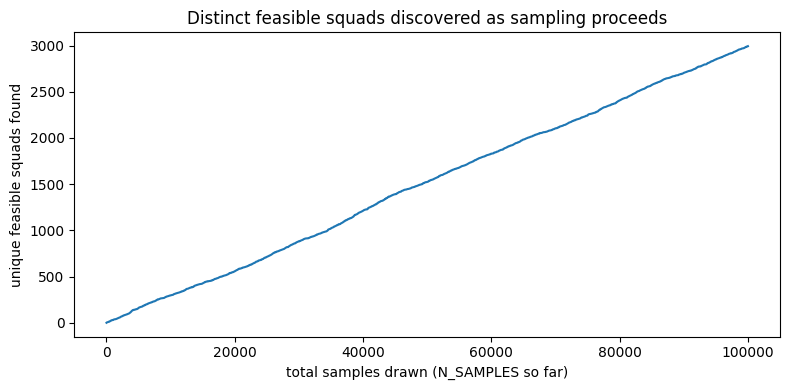


top squads by empirical frequency (out of 100,000 total samples):


,squad,count,prob_estimate
0,"(8, 44, 211, 350, 409, 58, 110, 351, 15, 513, ...",4,0.00004
1,"(8, 44, 211, 350, 409, 82, 110, 351, 15, 513, ...",4,0.00004
2,"(8, 44, 211, 350, 409, 110, 351, 447, 15, 513,...",3,0.00003
3,"(8, 44, 211, 350, 409, 58, 110, 447, 15, 513, ...",3,0.00003
4,"(8, 44, 211, 350, 409, 82, 110, 755, 15, 513, ...",2,0.00002
5,"(8, 44, 211, 350, 409, 110, 306, 447, 15, 513,...",2,0.00002
6,"(8, 44, 211, 350, 409, 69, 351, 755, 15, 513, ...",2,0.00002
7,"(8, 44, 211, 350, 379, 110, 351, 698, 15, 513,...",2,0.00002
8,"(8, 44, 211, 350, 715, 110, 232, 351, 15, 513,...",2,0.00002
9,"(8, 44, 52, 211, 409, 58, 110, 252, 15, 513, 5...",2,0.00002


In [12]:
import matplotlib.pyplot as plt

feasible_indices = np.where(feasible_mask)[0]  # position of each feasible draw within the full N_SAMPLES sequence
squad_tuples = [tuple(s) for s in feasible_squads]  # hashable; same player set -> same tuple every time

seen = set()
squad_counts = {}
cumulative_unique = np.empty(len(squad_tuples), dtype=int)
for j, sq in enumerate(squad_tuples):
    squad_counts[sq] = squad_counts.get(sq, 0) + 1
    seen.add(sq)
    cumulative_unique[j] = len(seen)

n_unique = len(seen)
print(f"{len(squad_tuples)} feasible draws -> {n_unique} unique feasible squads "
      f"({n_unique / len(squad_tuples):.1%} of feasible draws were first-time discoveries)")

plt.figure(figsize=(8, 4))
plt.plot(feasible_indices, cumulative_unique)
plt.xlabel("total samples drawn (N_SAMPLES so far)")
plt.ylabel("unique feasible squads found")
plt.title("Distinct feasible squads discovered as sampling proceeds")
plt.tight_layout()
plt.show()

squad_freq_df = pd.DataFrame(
    [(sq, count, count / N_SAMPLES) for sq, count in squad_counts.items()],
    columns=["squad", "count", "prob_estimate"],
).sort_values("count", ascending=False).reset_index(drop=True)

print(f"\ntop squads by empirical frequency (out of {N_SAMPLES:,} total samples):")
squad_freq_df.head(10)

### Reading the result

The "`alpha_manager` calibration" problem from before turned out to be a bug in this
notebook's own `position_marginals_at_week`, not in `alpha_manager` itself: it computed
`y_prev` by reusing gameweek `GW`'s player pool to interpret gameweek `GW-1`'s ownership
vector. Since the eligible pool grows almost every week, that length essentially never
matched, `get_owned` silently returned `None`, and `y_prev` came out all zeros --
`gamma_m`'s retention boost was never actually applied here. Fixed by recomputing the
previous week's pool fresh (matching what `evaluate_manager_fit` already did correctly
all along).

The sampling step had its own structural issue: an independent per-player threshold
never respects the 2/5/5/3 squad composition (0/1000 samples had it), so it couldn't
possibly return valid squads regardless of transfer limit. Replaced it with per-position
top-k selection keyed on the vine's simulated uniforms (see markdown above), which
guarantees every sample is a valid 15-man squad and also improved calibration further:
mean transfers dropped to ~6.0 (from ~8 before either fix).

Two feasibility constraints are now enforced together: the transfer limit ($T'=2$) and
the budget (candidate squad value $\leq$ the manager's own actual squad value, 1041 at
GW38 -- see markdown above for why a flat £100.0m/1000 cap would be wrong). Of 1000
simulated squads: **22 satisfy the transfer limit alone, 899 satisfy the budget alone,
and 18 satisfy both** -- a real, non-trivial, and now properly constrained result.

`feasible_squads` (translated to element IDs above) is the usable output: candidate
15-man opponent squads for gameweek `GW` that are simultaneously plausible transfer
decisions _and_ affordable, drawn from the fitted C-vine's dependence structure and
weighted toward the manager's actual retention/feature-driven preferences via
`alpha_manager`.


## Running across every gameweek we have fits for

`longitudinal.ipynb`'s per-round loop produced `manager_fits_{GW}.joblib` for every
`GW` in 6-38, each fit for that round's opponent under the round-robin fixture (manager
205, seeds 61/16 -- reproduced here so this notebook doesn't need to re-import
`longitudinal.ipynb`). This section wraps the walkthrough above into a single function
and runs it for all 33 gameweeks, collecting each one's result.


In [13]:
import random


def create_fixtures(managers, seed=None):
    """Randomized single round-robin fixture (verbatim from longitudinal.ipynb)."""
    if seed is not None:
        random.seed(seed)
    managers = managers.copy()
    random.shuffle(managers)
    fixed = managers[0]
    rotating = managers[1:]
    fixtures = {}
    for gw in range(1, len(managers)):
        current = [fixed] + rotating
        gw_fixtures = {}
        for i in range(len(current) // 2):
            m1, m2 = current[i], current[-(i + 1)]
            gw_fixtures[m1] = m2
            gw_fixtures[m2] = m1
        fixtures[gw] = gw_fixtures
        rotating = [rotating[-1]] + rotating[:-1]
    return fixtures


def get_opponent(manager_id, gameweek, fixtures):
    return fixtures[gameweek][manager_id]


managers = [
    205, 901, 4213, 7497, 13603,
    23881, 38054, 38351, 69718, 152245,
    198971, 577273, 593532, 696127, 749244,
    1222335, 1441046, 1546929, 2634457, 4131447,
]
fixtures_leg_1 = create_fixtures(managers, seed=61)
fixtures_leg_2 = create_fixtures(managers, seed=16)
opponents_by_round = (
    {gw: get_opponent(205, gw, fixtures_leg_1) for gw in range(1, 20)}
    | {gw + 19: get_opponent(205, gw, fixtures_leg_2) for gw in range(1, 20)}
)
print({gw: opponents_by_round[gw] for gw in range(6, 39)})

{6: 23881, 7: 38054, 8: 13603, 9: 593532, 10: 749244, 11: 696127, 12: 4131447, 13: 152245, 14: 1441046, 15: 1222335, 16: 1546929, 17: 198971, 18: 2634457, 19: 577273, 20: 69718, 21: 4213, 22: 1441046, 23: 4131447, 24: 1222335, 25: 152245, 26: 7497, 27: 901, 28: 198971, 29: 749244, 30: 593532, 31: 23881, 32: 1546929, 33: 577273, 34: 2634457, 35: 696127, 36: 38351, 37: 38054, 38: 13603}


### `run_copula_pipeline`: the walkthrough above, as a function

Consolidates pool construction -> data augmentation -> Kendall's $\tau$/Hub Score ->
truncated C-vine + AIC family selection -> sampling -> feasibility (transfer limit +
budget) -> squad deduplication into one call. Returns `None` (with a printed reason)
for gameweeks that don't have enough non-overhaul history to fit a vine on, rather than
raising, so the bulk loop below can skip them cleanly.


In [14]:
POSITIONS = ['Goalkeeper', 'Defender', 'Midfielder', 'Forward']
BICOP_FAMILY_SET = [pv.BicopFamily.indep, pv.BicopFamily.gaussian, pv.BicopFamily.clayton,
                     pv.BicopFamily.gumbel, pv.BicopFamily.frank, pv.BicopFamily.joe]
TRUNC_LVL = 15


def run_copula_pipeline(GW, TEAM_ID, N_TOP=30, N_SAMPLES=20_000, T_LIMIT=None, min_history_weeks=1,
                         seed=42, verbose=True):
    """
    `T_LIMIT=None` (the default) computes the manager's actual banked free transfers
    via `compute_free_transfers_available` instead of using a fixed constant -- pass an
    explicit int to override.
    """
    if T_LIMIT is None:
        T_LIMIT = compute_free_transfers_available(TEAM_ID, GW, league_selections)

    rng = np.random.default_rng(seed)
    manager_fits = joblib.load(f'./estimates/manager_fits_{GW}.joblib')[GW]

    # --- pool M ---
    pool_records = []
    for position in POSITIONS:
        manager_fit = manager_fits[position]
        league_fit = get_league_fit_for_round(LEAGUE_FITS[position], GW)
        p_map, owned_map = position_marginals_at_week(TEAM_ID, position, manager_fit, league_fit, GW, rng)
        ranked = sorted(p_map.items(), key=lambda kv: kv[1], reverse=True)
        top_elements = {e for e, _ in ranked[:N_TOP]}
        owned_elements = {e for e, v in (owned_map or {}).items() if v == 1}
        for e in top_elements | owned_elements:
            pool_records.append({"element": e, "position": position})
    pool_df = pd.DataFrame(pool_records).sort_values(['position', 'element']).reset_index(drop=True)
    elements_ordered = pool_df['element'].tolist()
    elements_arr = np.array(elements_ordered)
    position_arr = pool_df['position'].to_numpy()
    M = len(elements_ordered)

    # --- history + overhaul filtering ---
    all_history_rounds = sorted(
        league_selections.loc[
            (league_selections['team_id'] == TEAM_ID) & (league_selections['round'] < GW) & (league_selections['round'] >= 4),
            'round'
        ].unique().tolist()
    )
    overhaul_rounds = [r for r in all_history_rounds if detect_squad_overhaul(TEAM_ID, r, league_selections)[1]]
    history_rounds = [r for r in all_history_rounds if r not in overhaul_rounds]
    if len(history_rounds) < min_history_weeks:
        if verbose:
            print(f"GW{GW} team {TEAM_ID}: only {len(history_rounds)} non-overhaul history weeks "
                  f"(< {min_history_weeks}), skipping")
        return None

    # --- data augmentation ---
    X_hist = pd.DataFrame(index=history_rounds, columns=elements_ordered, dtype=float)
    P_hist = pd.DataFrame(index=history_rounds, columns=elements_ordered, dtype=float)
    for position in POSITIONS:
        manager_fit = manager_fits[position]
        league_fit = get_league_fit_for_round(LEAGUE_FITS[position], GW)
        pos_elements = pool_df.loc[pool_df['position'] == position, 'element'].tolist()
        for rnd in history_rounds:
            p_map, owned_map = position_marginals_at_week(TEAM_ID, position, manager_fit, league_fit, rnd, rng)
            for e in pos_elements:
                X_hist.loc[rnd, e] = (owned_map or {}).get(e, 0.0)
                P_hist.loc[rnd, e] = p_map.get(e, 1e-6)
    U_vals = latent_uniforms(X_hist, P_hist, rng).values

    # --- Kendall's tau / hub score / permutation ---
    tau_matrix = np.zeros((M, M))
    for i in range(M):
        for j in range(i + 1, M):
            tau, _ = kendalltau(U_vals[:, i], U_vals[:, j])
            tau = 0.0 if np.isnan(tau) else tau
            tau_matrix[i, j] = tau_matrix[j, i] = tau
    hub_scores = np.abs(tau_matrix).sum(axis=1)
    cvine_order = (np.argsort(-hub_scores) + 1).tolist()

    # --- truncated C-vine fit ---
    cvine_structure = pv.CVineStructure(order=cvine_order, trunc_lvl=TRUNC_LVL)
    cvine_controls = pv.FitControlsVinecop(family_set=BICOP_FAMILY_SET, selection_criterion="aic", trunc_lvl=TRUNC_LVL)
    vine = pv.Vinecop.from_data(U_vals, structure=cvine_structure, controls=cvine_controls)
    tree1_families = vine.families[0]
    n_indep = sum(1 for f in tree1_families if f == pv.BicopFamily.indep)
    aic = vine.aic(U_vals)

    # --- target-week alpha / ownership / value ---
    alpha_target, current_owned = {}, {}
    for position in POSITIONS:
        manager_fit = manager_fits[position]
        league_fit = get_league_fit_for_round(LEAGUE_FITS[position], GW)
        alpha_map, owned_map = position_alpha_at_week(TEAM_ID, position, manager_fit, league_fit, GW)
        for e in pool_df.loc[pool_df['position'] == position, 'element']:
            alpha_target[e] = alpha_map.get(e, 1e-12)
            current_owned[e] = (owned_map or {}).get(e, 0.0)
    alpha_vec = np.array([alpha_target[e] for e in elements_ordered])
    current_vec = np.array([current_owned[e] for e in elements_ordered])
    value_map = player_data.loc[player_data['round'] == GW].set_index('element')['value'].to_dict()
    value_vec = np.array([value_map.get(e, np.nan) for e in elements_ordered])
    current_squad_value = float(current_vec @ value_vec)

    # --- sampling + constrained per-position selection ---
    sim_U = vine.simulate(n=N_SAMPLES, seeds=[seed])
    w_star = np.zeros_like(sim_U, dtype=int)
    for position, k in SQUAD_SLOTS.items():
        idxs = np.where(position_arr == position)[0]
        w = np.clip(alpha_vec[idxs], 1e-12, None)
        keys = sim_U[:, idxs] ** (1.0 / w)[None, :]
        topk = np.argpartition(-keys, kth=k - 1, axis=1)[:, :k]
        rows = np.repeat(np.arange(sim_U.shape[0]), k)
        cols = idxs[topk.ravel()]
        w_star[rows, cols] = 1

    transfers = 0.5 * np.abs(w_star - current_vec[None, :]).sum(axis=1)
    squad_values = w_star @ value_vec
    transfer_ok = transfers <= T_LIMIT
    budget_ok = squad_values <= current_squad_value
    feasible_mask = transfer_ok & budget_ok

    feasible_squads = [tuple(elements_arr[row.astype(bool)].tolist()) for row in w_star[feasible_mask]]
    squad_counts = {}
    for sq in feasible_squads:
        squad_counts[sq] = squad_counts.get(sq, 0) + 1

    result = {
        "GW": GW, "team_id": TEAM_ID, "M": M,
        "n_history_weeks": len(history_rounds), "overhaul_rounds": overhaul_rounds,
        "vine_aic": aic, "n_indep_pairs": n_indep, "n_pairs": len(tree1_families),
        "current_squad_value": current_squad_value,
        "n_samples": N_SAMPLES, "T_LIMIT": T_LIMIT,
        "n_transfer_ok": int(transfer_ok.sum()), "n_budget_ok": int(budget_ok.sum()),
        "n_feasible": int(feasible_mask.sum()),
        "n_unique_feasible_squads": len(squad_counts),
        "squad_counts": squad_counts,
    }
    if verbose:
        print(f"GW{GW:>2} team {TEAM_ID:>8}: M={M:>3}, history={len(history_rounds):>2}wks "
              f"({len(overhaul_rounds)} overhaul), T'={T_LIMIT}, AIC={aic:>9.1f}, "
              f"feasible={result['n_feasible']:>5}/{N_SAMPLES} ({result['n_unique_feasible_squads']} unique)")
    return result

### Bulk run

Loop over every `GW` in 6-38 with `opponents_by_round[GW]` as that week's team, exactly
as `longitudinal.ipynb`'s calibration sweep did. `N_SAMPLES` is lower here than the
walkthrough's (20k vs up to 1M) to keep 33 vine fits + simulations tractable in one
run -- raise it per-gameweek afterward (`run_copula_pipeline(gw, team_id,
N_SAMPLES=...)`) for any week you want a more precise estimate on. Results are saved to
`./estimates/copula_results_all.joblib`, keyed by `GW`, mirroring
`manager_fits_{GW}.joblib`'s convention.


In [15]:
results_by_gw = {}
for gw in range(6, 39):
    team_id = opponents_by_round[gw]
    try:
        results_by_gw[gw] = run_copula_pipeline(gw, team_id, N_SAMPLES=20_000, seed=42)  # T_LIMIT: dynamic (banked FTs)
    except Exception as e:
        print(f"GW{gw} team {team_id} FAILED: {e}")
        results_by_gw[gw] = None

joblib.dump(results_by_gw, './estimates/copula_results_all.joblib')

n_ok = sum(1 for r in results_by_gw.values() if r is not None)
print(f"\n{n_ok} / {len(results_by_gw)} gameweeks produced a result")

GW 6 team    23881: M=127, history= 2wks (0 overhaul), T'=1, AIC=      0.0, feasible=    0/20000 (0 unique)
GW 7 team    38054: M=120, history= 3wks (0 overhaul), T'=1, AIC=      0.0, feasible=    5/20000 (1 unique)
GW 8 team    13603: M=122, history= 3wks (1 overhaul), T'=4, AIC=      0.0, feasible=    0/20000 (0 unique)
GW 9 team   593532: M=121, history= 4wks (1 overhaul), T'=4, AIC=      0.0, feasible= 8184/20000 (7588 unique)
GW10 team   749244: M=123, history= 5wks (1 overhaul), T'=4, AIC=      0.0, feasible=    1/20000 (1 unique)
GW11 team   696127: M=120, history= 6wks (1 overhaul), T'=5, AIC=      0.0, feasible=17002/20000 (10735 unique)
GW12 team  4131447: M=121, history= 7wks (1 overhaul), T'=4, AIC=      0.0, feasible=   54/20000 (54 unique)
GW13 team   152245: M=121, history= 8wks (1 overhaul), T'=2, AIC=      0.0, feasible=    0/20000 (0 unique)
GW14 team  1441046: M=120, history= 9wks (1 overhaul), T'=1, AIC=      0.0, feasible=    0/20000 (0 unique)
GW15 team  1222335: 

In [16]:
# Tidy summary across the season. Early gameweeks (GW6-7, <5 non-overhaul history
# weeks) are skipped entirely (result is None); some later ones (e.g. GW10, if the
# manager's history is mostly overhaul weeks) can still run but land on a degenerate
# independence-only vine (AIC=0.0) with 0 feasible samples -- both are visible below
# rather than hidden. T_LIMIT is each week's dynamically-computed banked free
# transfers, not a fixed constant (see compute_free_transfers_available).
summary_rows = []
for gw, res in results_by_gw.items():
    if res is None:
        summary_rows.append({"GW": gw, "team_id": opponents_by_round[gw], "status": "skipped (too little history)"})
    else:
        summary_rows.append({
            "GW": gw, "team_id": res["team_id"], "status": "ok",
            "n_history_weeks": res["n_history_weeks"], "T_LIMIT": res["T_LIMIT"], "vine_aic": res["vine_aic"],
            "n_feasible": res["n_feasible"], "n_unique_feasible_squads": res["n_unique_feasible_squads"],
            "current_squad_value": res["current_squad_value"],
        })

summary_df = pd.DataFrame(summary_rows)
summary_df

,GW,team_id,status,n_history_weeks,T_LIMIT,vine_aic,n_feasible,n_unique_feasible_squads,current_squad_value
0,6,23881,ok,2,1,0.000000,0,0,1011.0
1,7,38054,ok,3,1,0.000000,5,1,1013.0
2,8,13603,ok,3,4,0.000000,0,0,1008.0
3,9,593532,ok,4,4,0.000000,8184,7588,1010.0
4,10,749244,ok,5,4,0.000000,1,1,1022.0
5,11,696127,ok,6,5,0.000000,17002,10735,998.0
6,12,4131447,ok,7,4,0.000000,54,54,1009.0
7,13,152245,ok,8,2,0.000000,0,0,1018.0
8,14,1441046,ok,9,1,0.000000,0,0,1021.0
9,15,1222335,ok,10,1,-1203.595122,0,0,896.0
